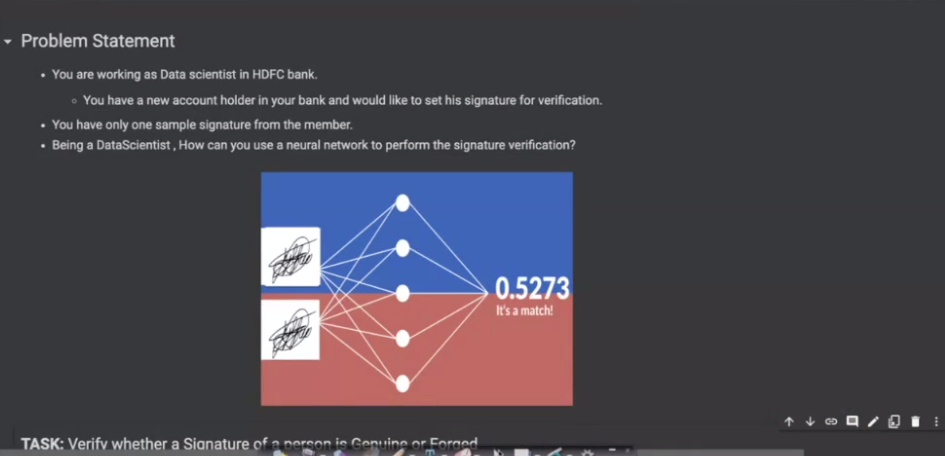

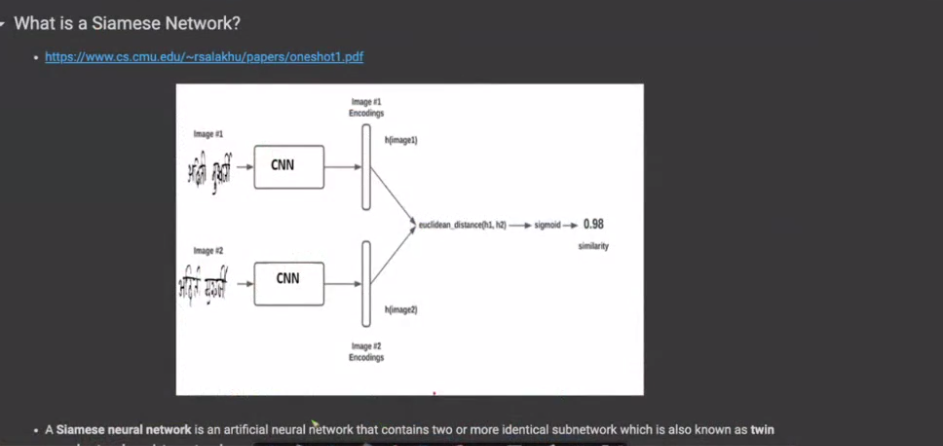

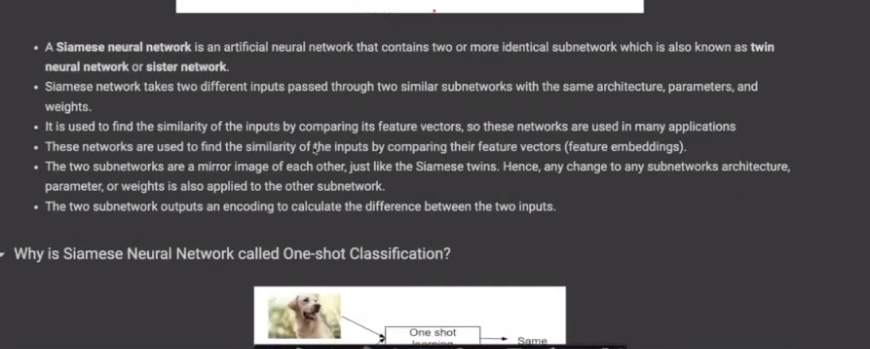

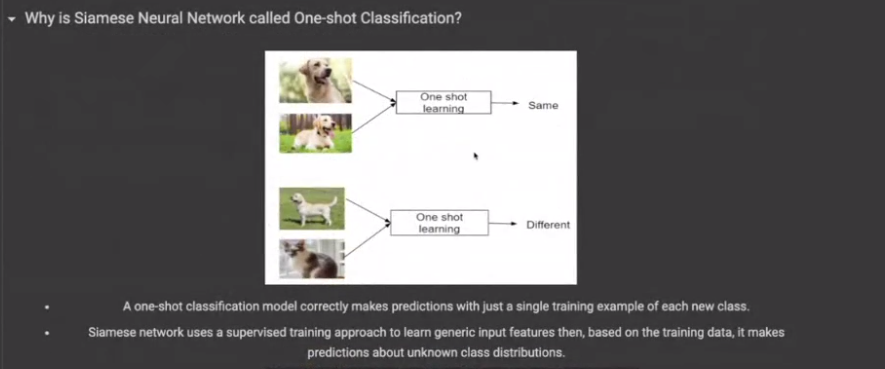

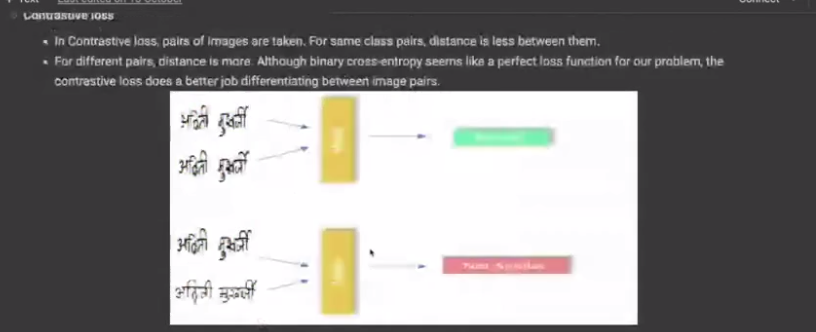

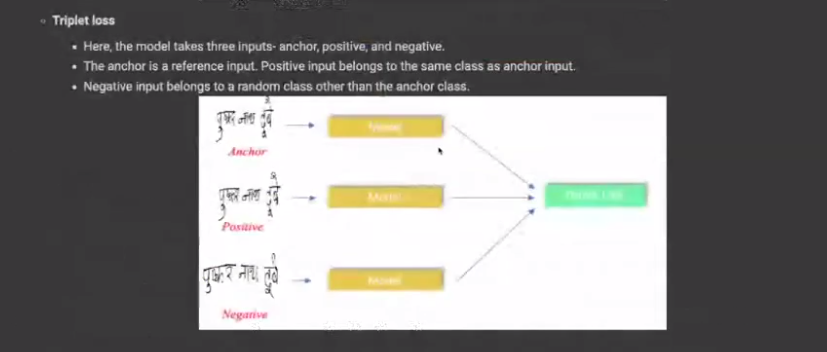

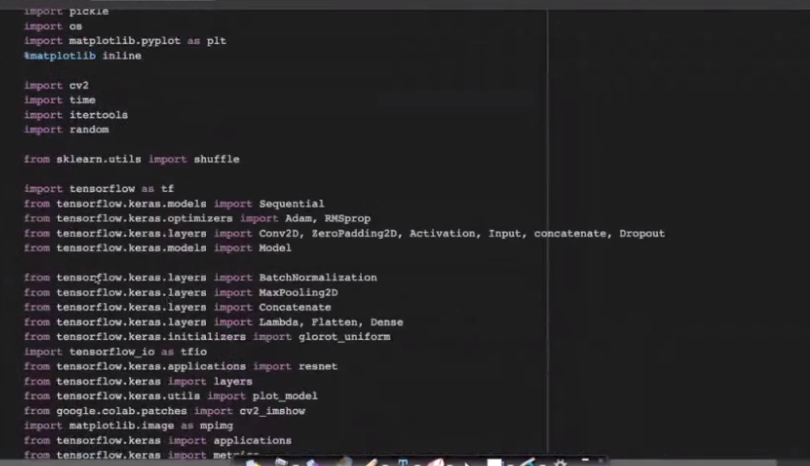

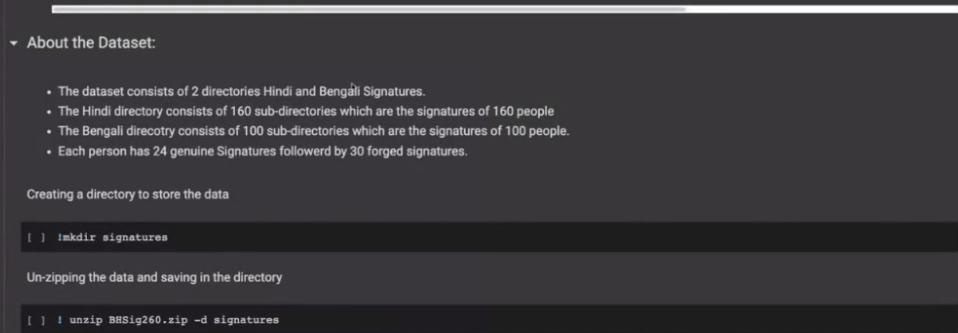

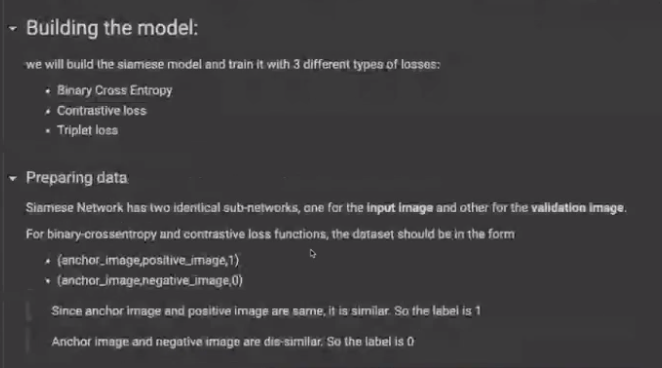

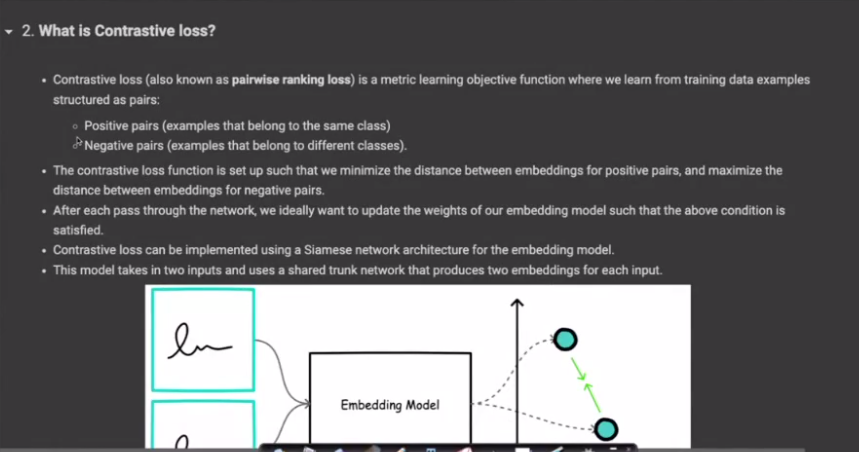

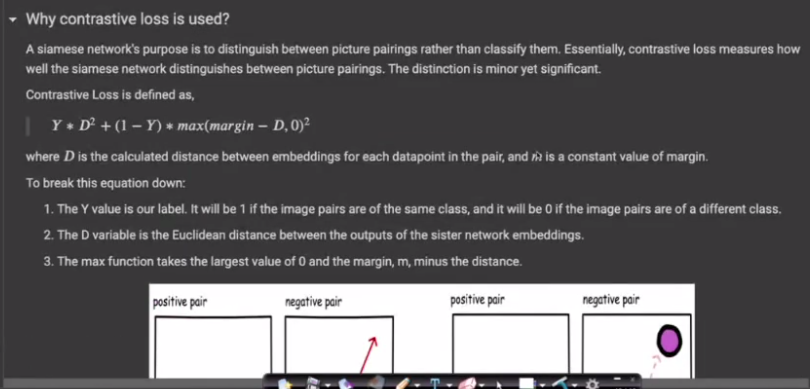

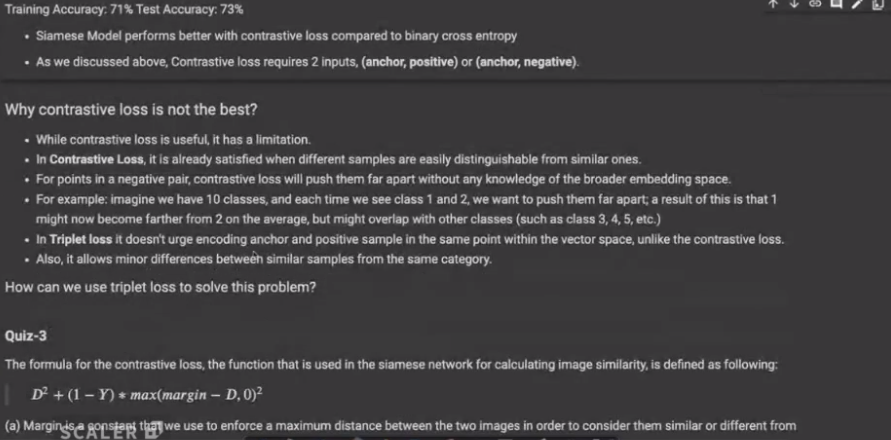

```markdown
# Siamese Networks and Loss Functions

Siamese networks are a class of neural network architectures that use two or more identical subnetworks to process two or more input samples, respectively. They are particularly useful for tasks that involve comparing two inputs to determine their similarity or dissimilarity, rather than classifying them into predefined categories. This makes them ideal for applications such as:

*   **Signature verification**
*   **Face recognition**
*   **One-shot learning**
*   **Image retrieval**

## Core Idea

The fundamental principle behind a Siamese network is to learn a mapping function that transforms input data into a new feature space. In this feature space, the distance between the representations of similar inputs should be small, while the distance between dissimilar inputs should be large.

```

```markdown
## Architecture of a Siamese Network

A typical Siamese network consists of the following components:

1.  **Two Identical Subnetworks (Branches):** These are usually convolutional neural networks (CNNs) that share the exact same architecture and weights. This sharing of weights is crucial as it ensures that both branches learn the same transformation function, mapping inputs to a comparable feature space.

2.  **Input Pairs/Triplets:** Instead of single inputs, Siamese networks take pairs of inputs (for similarity/dissimilarity tasks) or triplets of inputs (for more complex ranking tasks).

3.  **Distance Metric:** After the subnetworks produce feature vectors (embeddings) for their respective inputs, a distance metric (e.g., Euclidean distance, cosine similarity) is used to quantify the similarity or dissimilarity between these embeddings.

4.  **Loss Function:** A specialized loss function is used to train the network. This loss function is designed to minimize the distance for similar pairs and maximize the distance for dissimilar pairs.

```

```markdown
## Loss Functions for Siamese Networks

The choice of loss function is critical for effectively training a Siamese network. The primary goal of these loss functions is to push similar samples closer in the embedding space and dissimilar samples further apart.

### 1. Contrastive Loss

Contrastive loss is one of the most common loss functions used in Siamese networks. It operates on pairs of samples and aims to reduce the distance between positive pairs (similar samples) and increase the distance between negative pairs (dissimilar samples), up to a certain margin.

The formula for contrastive loss for a pair of embeddings $(h_1, h_2)$ and a label $y$ (where $y=0$ for similar, $y=1$ for dissimilar) is:

$L(h_1, h_2, y) = y \cdot \frac{1}{2} D_{W}^2 + (1-y) \cdot \frac{1}{2} \max(0, m - D_{W})^2$

Where:
*   $D_{W}$ is the Euclidean distance (or another distance metric) between $h_1$ and $h_2$.
*   $m$ is a **margin** hyperparameter. It represents the minimum desired distance between dissimilar pairs.

**Explanation:**
*   If $y=0$ (similar pair): The loss is $\frac{1}{2} D_{W}^2$. The network tries to minimize the distance between $h_1$ and $h_2$.
*   If $y=1$ (dissimilar pair): The loss is $\frac{1}{2} \max(0, m - D_{W})^2$. The network tries to push $h_1$ and $h_2$ at least `m` distance apart. If $D_W$ is already greater than `m`, the loss for this term becomes zero, meaning the samples are sufficiently separated.

```

In [ ]:
```python
import tensorflow as tf

def contrastive_loss(y_true, y_pred, margin=1.0):
    # y_true: 0 for similar, 1 for dissimilar
    # y_pred: Euclidean distance between embeddings

    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

# Example usage (conceptual)
# h1 = tf.random.normal((1, 128)) # Embedding for image 1
# h2 = tf.random.normal((1, 128)) # Embedding for image 2
# distance = tf.norm(h1 - h2, axis=1) # Euclidean distance
# y = tf.constant([0.0]) # Label: similar
# loss = contrastive_loss(y, distance)
# print(f"Contrastive Loss: {loss}")
```

```markdown
### 2. Triplet Loss

Triplet loss works with triplets of samples: an **anchor** ($A$), a **positive** ($P$) sample (similar to $A$), and a **negative** ($N$) sample (dissimilar to $A$). The goal is to ensure that the anchor is closer to the positive sample than to the negative sample by a certain margin.

The formula for triplet loss for embeddings $(h_A, h_P, h_N)$ is:

$L(h_A, h_P, h_N) = \max(0, D(h_A, h_P)^2 - D(h_A, h_N)^2 + m)$

Where:
*   $D(h_A, h_P)$ is the distance between the anchor and the positive sample.
*   $D(h_A, h_N)$ is the distance between the anchor and the negative sample.
*   $m$ is a **margin** hyperparameter, which enforces a minimum difference between the positive and negative distances.

**Explanation:**
The network is trained such that:
*   The distance between the anchor and the positive ($D(h_A, h_P)$) is minimized.
*   The distance between the anchor and the negative ($D(h_A, h_N)$) is maximized, ensuring it's at least `m` greater than $D(h_A, h_P)$.
*   If $D(h_A, h_N)^2$ is already sufficiently larger than $D(h_A, h_P)^2 + m$, the loss becomes zero.

**Advantages of Triplet Loss:**
*   Directly optimizes for relative distances, which can lead to better separation.
*   Can be more robust to variations within a class.

**Challenges with Triplet Loss:**
*   **Triplet Mining:** The choice of triplets significantly impacts training effectiveness. Poorly chosen triplets (e.g., easy negatives that are already far from the anchor) can lead to slow convergence or suboptimal embeddings. Strategies like **hard negative mining** (selecting negative samples that are close to the anchor) are often used.

```

In [ ]:
```python
import tensorflow as tf

def triplet_loss(anchor, positive, negative, margin=0.2):
    # anchor, positive, negative: Embeddings from the Siamese network

    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1) # Squared Euclidean distance
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)

    basic_loss = pos_dist - neg_dist + margin
    loss = tf.reduce_mean(tf.maximum(basic_loss, 0.0))
    return loss

# Example usage (conceptual)
# h_A = tf.random.normal((1, 128)) # Embedding for anchor
# h_P = tf.random.normal((1, 128)) # Embedding for positive
# h_N = tf.random.normal((1, 128)) # Embedding for negative
# loss = triplet_loss(h_A, h_P, h_N)
# print(f"Triplet Loss: {loss}")
```

```markdown
### Other Loss Functions

While contrastive and triplet losses are the most prominent, other loss functions or variations can also be used:

*   **Quadruplet Loss:** An extension of triplet loss that uses four samples (anchor, positive, negative_1, negative_2) to enforce even stronger separation.
*   **N-pair Loss:** Generalizes triplet loss to multiple negative samples per anchor, making training more efficient.
*   **Margin-based Softmax Loss:** Combines traditional softmax with a margin to encourage more discriminative feature learning.

## Training a Siamese Network

Training a Siamese network involves:

1.  **Data Preparation:** Creating appropriate pairs or triplets of data (e.g., pairs of similar images, pairs of dissimilar images, or anchor-positive-negative triplets).
2.  **Subnetwork Design:** Choosing a suitable base network (e.g., ResNet, VGG) for your specific data type (images, text, etc.).
3.  **Loss Function Selection:** Deciding on the most appropriate loss function and its hyperparameters (like the margin).
4.  **Optimization:** Using standard optimization algorithms (e.g., Adam, SGD) to minimize the chosen loss function.

Siamese networks are powerful tools for learning similarity, making them invaluable in various machine learning tasks where direct classification might be less effective or data is scarce.
```